Defaulting to user installation because normal site-packages is not writeable


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                          Email Text      Email Type
0  re : 6 . 1100 , disc : uniformitarianism , re ...      Safe Email
1  the other side of * galicismos * * galicismo *...      Safe Email
2  re : equistar deal tickets are you still avail...      Safe Email
3  \nHello I am your hot lil horny toy.\n    I am...  Phishing Email
4  software at incredibly low prices ( 86 % lower...  Phishing Email
5  global risk management operations sally congra...      Safe Email
6  On Sun, Aug 11, 2002 at 11:17:47AM +0100, wint...      Safe Email
7  entourage , stockmogul newsletter ralph velez ...  Phishing Email
8  we owe you lots of money dear applicant , afte...  Phishing Email
9  re : coastal deal - with exxon participation u...      Safe Email 

Index(['Email Text', 'Email Type'], dtype='object')
Email Text    0.0
Email Type    0.0
dtype: float64
Data cleaning complete!!! file saved as news.csv

                                           Email Text  Email Type
0  6 1100 disc unifo

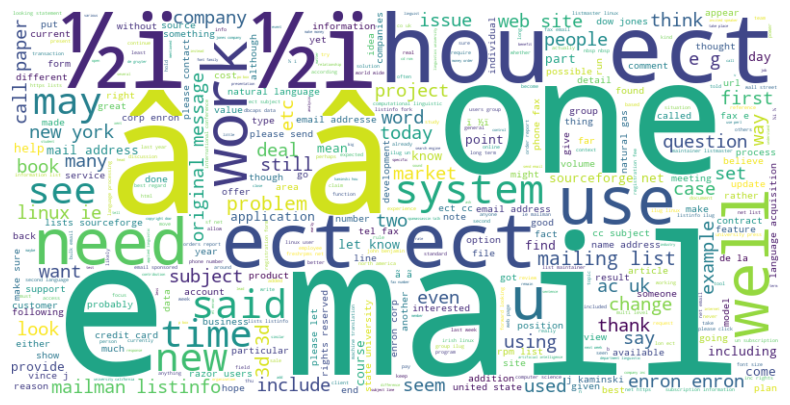

Naive Bayes Accuracy: 0.948752347732761
              precision    recall  f1-score   support

           0       0.96      0.91      0.94      1518
           1       0.94      0.97      0.96      2209

    accuracy                           0.95      3727
   macro avg       0.95      0.94      0.95      3727
weighted avg       0.95      0.95      0.95      3727



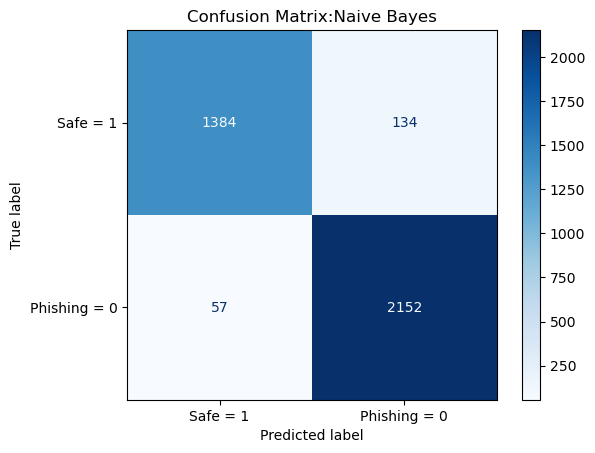


===ROC Curve===



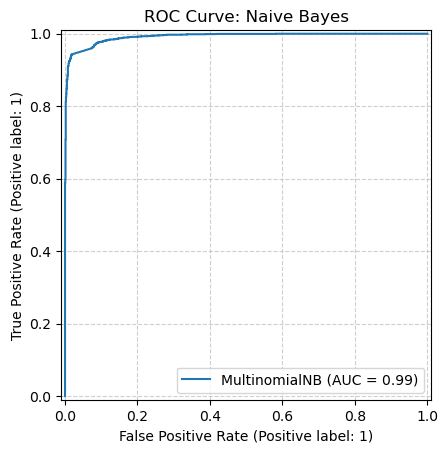

Logistic Regression Accuracy: 0.9661926482425544
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1518
           1       0.98      0.96      0.97      2209

    accuracy                           0.97      3727
   macro avg       0.96      0.97      0.97      3727
weighted avg       0.97      0.97      0.97      3727



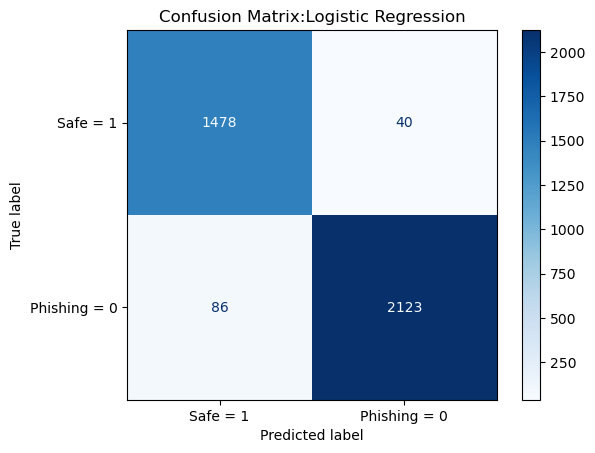


===ROC Curve===



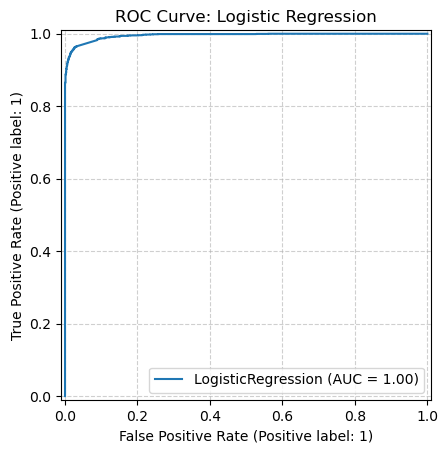

Decision Tree Accuracy: 0.9254091762811913
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1518
           1       0.95      0.92      0.94      2209

    accuracy                           0.93      3727
   macro avg       0.92      0.93      0.92      3727
weighted avg       0.93      0.93      0.93      3727



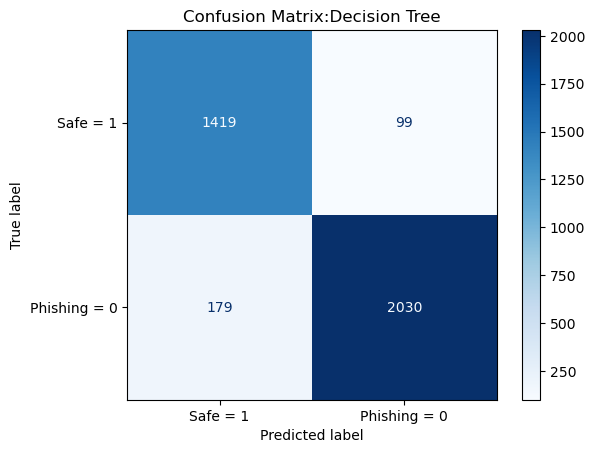


===ROC Curve===



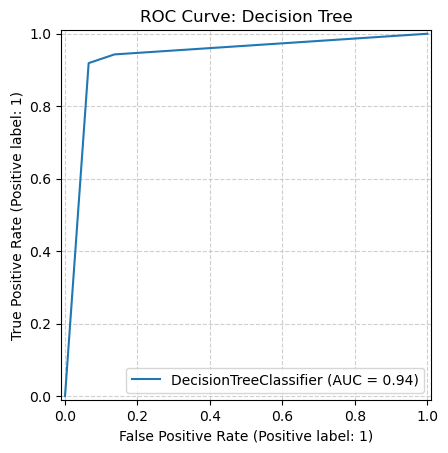

NeuralNet Accuracy: 0.9669975851891602
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1518
           1       0.98      0.96      0.97      2209

    accuracy                           0.97      3727
   macro avg       0.96      0.97      0.97      3727
weighted avg       0.97      0.97      0.97      3727



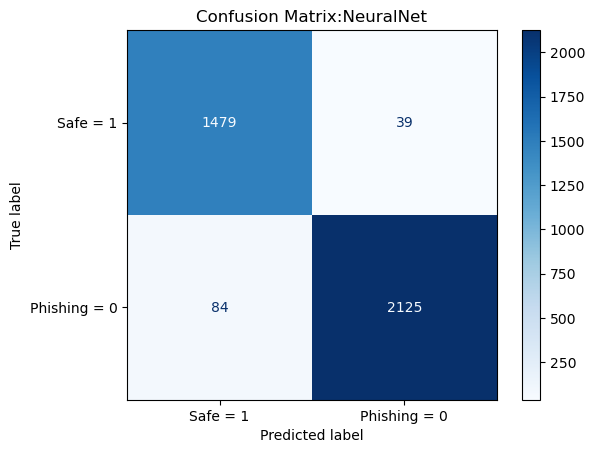


===ROC Curve===



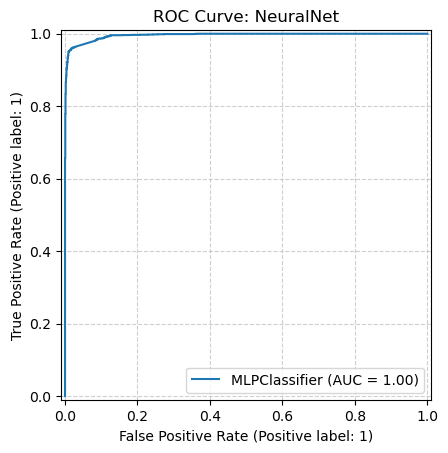

Random Forest Accuracy: 0.9627045881405957
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      1518
           1       0.98      0.95      0.97      2209

    accuracy                           0.96      3727
   macro avg       0.96      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



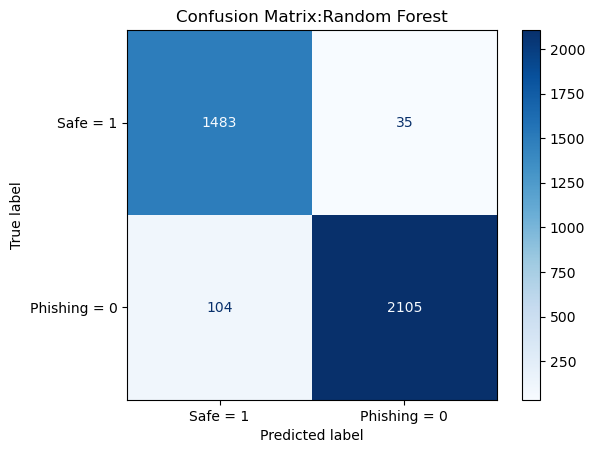


===ROC Curve===



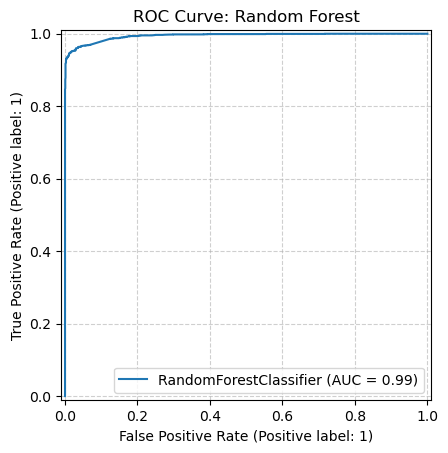

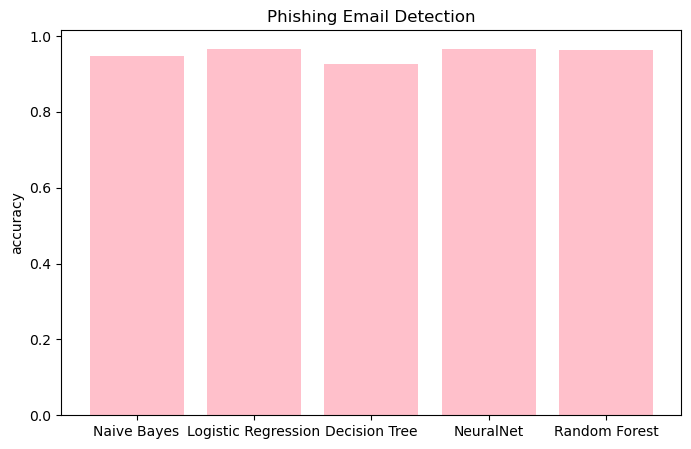

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import re
import string
from wordcloud import WordCloud
!pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

emails = pd.read_csv("Phishing_Email.csv", index_col = 0)
print(emails.head(10),"\n")
print(emails.columns)

#mappping categories to numbers
mapping = {'Safe Email': 1,  'Phishing Email': 0}
emails['Email Type'] = emails['Email Type'].map(mapping)

#drop missing values
emails = emails.dropna()
print(emails.isna().sum()*100/len(emails))

#data cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    words = text.split()
    stop_words = set(stopwords.words('english'))
    clean_words = [word for word in words if word not in stop_words]
    return " ".join(clean_words)
emails['Email Text']= emails['Email Text'].apply(clean_text)
emails.head(10)

emails.to_csv('cleaned_email_dataset.csv',index=False)
print("Data cleaning complete!!! file saved as news.csv")


X =emails['Email Text'] #email content
Y =emails['Email Type'] # safe = 1, phishing = 0
print("\n",emails.head(8))

#WORD CLOUDING
text = " ".join(emails['Email Text'].astype(str))
wordcloud= WordCloud(max_words = 400, width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis("off")
plt.show()

#vectorization
vectorizer = TfidfVectorizer(stop_words = 'english', max_features = 5000)
X_vec = vectorizer.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_vec, Y, test_size = 0.2, random_state = 42)

#model buliding
models = {
          "Naive Bayes" : MultinomialNB(),
          "Logistic Regression": LogisticRegression(max_iter=1000),
          "Decision Tree": DecisionTreeClassifier(),
          "NeuralNet": MLPClassifier(hidden_layer_sizes=(100, ), max_iter=300),
          "Random Forest": RandomForestClassifier(n_estimators= 200)
        }
name_list =[]
score =[]
for name, model in models.items():
    model.fit(X_train,Y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(Y_test,predictions)
    name_list.append(name)
    score.append(accuracy)
    print(f"{name} Accuracy:",accuracy)
    print(classification_report(Y_test, predictions, zero_division =0))

    #confusionmatrix
    confuse_mat = confusion_matrix(Y_test, predictions)
    display = ConfusionMatrixDisplay(confusion_matrix = confuse_mat, display_labels = ['Safe = 1', 'Phishing = 0'])
    display.plot(cmap ='Blues', values_format = 'd')
    plt.title(f"Confusion Matrix:{name}")
    plt.show()
    #ROC CURVE
    print("\n===ROC Curve===\n")
    RocCurveDisplay.from_estimator(model, X_test, Y_test)
    plt.title(f"ROC Curve: {name}")
    plt.grid(True, linestyle='--', alpha= 0.6)
    plt.show()

#bar chart
plt.figure(figsize=(8, 5))
plt.bar(name_list, score, color = 'pink')
plt.title('Phishing Email Detection')
plt.ylabel('accuracy')
plt.show()